In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os

In [ ]:
DRIVE_ROOT = "/content/drive/MyDrive/Aegis-CyberSec-Guard"
DATA_DIR = os.path.join(DRIVE_ROOT, "netguard", "dataV1")

In [ ]:
LOCAL_DIR = "/content/netguard_train"
CKPT_DIR = os.path.join(LOCAL_DIR, "checkpoints")
DRIVE_OUT = os.path.join(DRIVE_ROOT, "netguard", "modelV1")


In [ ]:
KERNEL_SIZES = (3, 5, 7)
NUM_FILTERS = 64
DROPOUT = 0.3
HIDDEN_DIM = 128
BATCH_SIZE = 1024  # 2M rows, small model — large batches are cheap and fast
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
EARLY_STOP_PATIENCE = 4

In [ ]:
# Inverse-frequency weights, capped so the near-empty "Other" class (36 train samples)
# doesn't get an absurd weight that destabilizes training. None = auto-computed.
MAX_CLASS_WEIGHT_RATIO = 15.0

In [ ]:
# Sanity thresholds for the inspection cell
MAX_SANE_ABS_VALUE = 1000.0

In [ ]:
SEED = 3407

In [ ]:
os.makedirs(CKPT_DIR, exist_ok=True)
print(f"Reading tensors from: {DATA_DIR}")
print(f"Final artifacts to:   {DRIVE_OUT}")

Reading tensors from: /content/drive/MyDrive/Aegis-CyberSec-Guard/netguard/dataV1
Final artifacts to:   /content/drive/MyDrive/Aegis-CyberSec-Guard/netguard/modelV1


## Import ML Libraries

In [ ]:
import json
import time
import shutil

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
# Imporr SciKit-Learn Metrics Functions

In [ ]:
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


In [ ]:
with open(os.path.join(DATA_DIR, "metadata.json")) as f:
    meta = json.load(f)

## Get Training and Val Tensors from ETL Pipeline

In [ ]:
X_train = np.load(os.path.join(DATA_DIR, "X_train.npy"))
y_train_mc = np.load(os.path.join(DATA_DIR, "y_train_multiclass.npy"))
y_train_bin = np.load(os.path.join(DATA_DIR, "y_train_binary.npy"))

In [ ]:
X_val = np.load(os.path.join(DATA_DIR, "X_val.npy"))
y_val_mc = np.load(os.path.join(DATA_DIR, "y_val_multiclass.npy"))
y_val_bin = np.load(os.path.join(DATA_DIR, "y_val_binary.npy"))

In [ ]:
X_test = np.load(os.path.join(DATA_DIR, "X_test.npy"))
y_test_mc = np.load(os.path.join(DATA_DIR, "y_test_multiclass.npy"))
y_test_bin = np.load(os.path.join(DATA_DIR, "y_test_binary.npy"))

In [ ]:
class_names = meta["class_names"]
N_FEATURES = X_train.shape[1]   # read from the actual tensor, not hardcoded .

In [ ]:
# Validation First just before  moving to dataset buidling and training CNN1D Model
print(" Shape s ")
for name, X, y in [("train", X_train, y_train_mc), ("val", X_val, y_val_mc), ("test", X_test, y_test_mc)]:
    print(f"  X_{name}: {X.shape}  y_{name}: {y.shape}  dtype: {X.dtype}")

print(f"n_features detected: {N_FEATURES}  (metadata says: {meta['n_features']})")
if N_FEATURES != meta["n_features"]:
    print("  NOTE: mismatch is expected/harmless if the Fwd Header Length.1 dedup was "
          "applied after metadata.json was last written. Proceeding with the real shape.")

print("Value ranges  - this is the check that matters")
for name, X in [("train", X_train), ("val", X_val), ("test", X_test)]:
    print(f"  X_{name}: mean={X.mean():.4f}  std={X.std():.4f}  "
          f"min={X.min():.2f}  max={X.max():.2f}  max_abs={np.abs(X).max():.2f}")


 Shape s 
  X_train: (1928410, 77)  y_train: (1928410,)  dtype: float32
  X_val: (340308, 77)  y_val: (340308,)  dtype: float32
  X_test: (252080, 77)  y_test: (252080,)  dtype: float32

n_features detected: 77  (metadata says: 77)

=== Value ranges (this is the check that matters) ===
  X_train: mean=0.9782  std=9.9140  min=-2.86  max=787.67  max_abs=787.67
  X_val: mean=0.9754  std=9.9694  min=-2.86  max=787.67  max_abs=787.67
  X_test: mean=0.9822  std=9.9135  min=-2.86  max=787.67  max_abs=787.67


In [ ]:
assert not np.isnan(X_train).any(), "NaN in X_train — the ETL's clip/scale step did not run cleanly"
assert not np.isinf(X_train).any(), "Infinity in X_train — same failure mode as the raw CICIDS2017 columns"

In [ ]:
max_abs = np.abs(X_train).max()

In [ ]:
if max_abs > MAX_SANE_ABS_VALUE:
    raise RuntimeError(
        f"X_train has values up to {max_abs:.2e}, which is the BROKEN RobustScaler output "
        f"from earlier today (a near-zero IQR column, e.g. 'Fwd Header Length', blew up the "
        f"scale). This is almost certainly the pre-fix save. Go back to the ETL notebook, "
        f"re-run from the winsorize+scale cell (the one using np.percentile clipping) through "
        f"the Drive copy cell, and re-run this notebook after. Do NOT train on this."
    )
print(f"\nScale check passed: max |value| = {max_abs:.2f} (sane range).")



Scale check passed: max |value| = 787.67 (sane range).


In [ ]:
print("Class distribution in loaded X_train vs metadata's recorded distribution:")
recorded = meta["class_distribution_train"]
for i, name in enumerate(class_names):
    actual = int((y_train_mc == i).sum())
    expected = recorded.get(name, "?")
    match = "OK" if actual == expected else "MISMATCH"
    print(f"  {name:12s} actual={actual:>9,}  recorded={expected!s:>9}  [{match}]")


Class distribution in loaded X_train vs metadata's recorded distribution:
  BENIGN       actual=1,602,718  recorded=  1602718  [OK]
  Bot          actual=    1,490  recorded=     1490  [OK]
  BruteForce   actual=    7,000  recorded=     7000  [OK]
  DDoS         actual=   97,931  recorded=    97931  [OK]
  DoS          actual=  148,214  recorded=   148214  [OK]
  PortScan     actual=   69,381  recorded=    69381  [OK]
  WebAttack    actual=    1,640  recorded=     1640  [OK]
  Other        actual=       36  recorded=       36  [OK]


##  Cross-check class distribution against metadata
A second independent check: if the ETL saved a stale/different split, this catches it.

In [ ]:
print("Class distribution in loaded X_train vs metadata's recorded distribution:")
recorded = meta["class_distribution_train"]
for i, name in enumerate(class_names):
    actual = int((y_train_mc == i).sum())
    expected = recorded.get(name, "?")
    match = "OK" if actual == expected else "MISMATCH"
    print(f"  {name:12s} actual={actual:>9,}  recorded={expected!s:>9}  [{match}]")


Class distribution in loaded X_train vs metadata's recorded distribution:
  BENIGN       actual=1,602,718  recorded=  1602718  [OK]
  Bot          actual=    1,490  recorded=     1490  [OK]
  BruteForce   actual=    7,000  recorded=     7000  [OK]
  DDoS         actual=   97,931  recorded=    97931  [OK]
  DoS          actual=  148,214  recorded=   148214  [OK]
  PortScan     actual=   69,381  recorded=    69381  [OK]
  WebAttack    actual=    1,640  recorded=     1640  [OK]
  Other        actual=       36  recorded=       36  [OK]


In [ ]:
# Cross-check derived binary against the separately-saved binary tensor — they were built
# from the same "is_attack" column in the ETL, so they must agree exactly.
benign_idx = class_names.index("BENIGN")
derived_binary = (y_train_mc != benign_idx).astype(np.int32)
assert np.array_equal(derived_binary, y_train_bin), (
    "Derived binary (multiclass != BENIGN) disagrees with the saved binary tensor — "
    "the two were supposed to be built from the same source column in the ETL."
)
print("\nBinary/multiclass consistency check passed.")



Binary/multiclass consistency check passed.


##  DataLoaders

In [ ]:
def make_loader(X, y, batch_size, shuffle):
    ds = TensorDataset(
        torch.from_numpy(X).float(),
        torch.from_numpy(y).long(),
    )
    return DataLoader(ds,
                      batch_size=batch_size,
                      shuffle=shuffle,
                      num_workers=2,
                      pin_memory=True
                      )

In [ ]:
train_loader = make_loader(X_train, y_train_mc, BATCH_SIZE, shuffle=True)
val_loader = make_loader(X_val, y_val_mc, BATCH_SIZE, shuffle=False)
test_loader = make_loader(X_test, y_test_mc, BATCH_SIZE, shuffle=False)


In [ ]:
print(f"train batches: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")

train batches: 1884 | val: 333 | test: 247


In [ ]:
## Passed.

##  Model definition

Same TextCNN-family design as LogSentinel (parallel multi-kernel branches + global max pool),

but NO embedding layer: input is already a scaled float feature vector, reshaped to (batch, 1 channel, N_FEATURES) and treated as a 1D signal directly.


In [ ]:

class NetGuard(nn.Module):
    def __init__(
        self,
        n_features,
        n_classes,
        kernel_sizes=KERNEL_SIZES,
        num_filters=NUM_FILTERS,
        hidden_dim=HIDDEN_DIM,
        dropout=DROPOUT,
    ):
        super().__init__()

        # Kernels must not exceed the feature count (unlike LogSentinel's 40-length
        # sequences, N_FEATURES could in principle be small - guard against it).
        valid_kernels = [k for k in kernel_sizes if k <= n_features]
        if len(valid_kernels) < len(kernel_sizes):
            dropped = set(kernel_sizes) - set(valid_kernels)
            print(f"WARNING: dropping kernel sizes {dropped} — larger than n_features={n_features}")

        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=1,
                      out_channels=num_filters,
                      kernel_size=k
                      )
            for k in valid_kernels
        ])

        concat_dim = num_filters * len(valid_kernels)

        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(concat_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, n_classes)

    def forward(self, x):
        # x: (batch, n_features) float -> (batch, 1, n_features) for Conv1d
        x = x.unsqueeze(1)

        pooled = []
        for conv in self.convs:
            h = F.relu(conv(x))
            h = F.max_pool1d(h, kernel_size=h.shape[2]).squeeze(2)
            pooled.append(h)

        h = torch.cat(pooled, dim=1)
        h = self.dropout(h)
        h = F.relu(self.fc1(h))
        h = self.dropout(h)
        # raw logits, (batch, n_classes) — softmax applied only at eval
        return self.fc2(h)



In [ ]:
model = NetGuard(n_features=N_FEATURES, n_classes=len(class_names)).to(DEVICE)

In [ ]:
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
print(model)
print(f"\nTrainable parameters: {n_params:,}")
print(f"Approx size in fp32: {n_params * 4 / 1e6:.2f} MB")

NetGuard(
  (convs): ModuleList(
    (0): Conv1d(1, 64, kernel_size=(3,), stride=(1,))
    (1): Conv1d(1, 64, kernel_size=(5,), stride=(1,))
    (2): Conv1d(1, 64, kernel_size=(7,), stride=(1,))
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=192, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=8, bias=True)
)

Trainable parameters: 26,888
Approx size in fp32: 0.11 MB


In [ ]:
xb, yb = next(iter(train_loader))
print(f"input batch:  {tuple(xb.shape)}  dtype={xb.dtype}")

input batch:  (1024, 77)  dtype=torch.float32


In [ ]:
with torch.no_grad():
    out = model(xb.to(DEVICE))

In [ ]:
print(f"output batch: {tuple(out.shape)}  dtype={out.dtype}")
assert out.shape == (xb.shape[0], len(class_names)), "unexpected output shape"
print("Shape check passed.")

output batch: (1024, 8)  dtype=torch.float32
Shape check passed.


## **Class weights, Loss, Optimizer**

Inverse-frequency weighting, same principle as LogSentinel's pos_weight but generalized to N classes via CrossEntropyLoss's per-class weight vector. Capped at MAX_CLASS_WEIGHT_RATIO so "Other" (36 train samples — too few to learn from regardless of weighting) doesn't get an absurd weight that destabilizes every other class.

In [ ]:
class_counts = np.bincount(y_train_mc,
                           minlength=len(class_names)
                           )
inv_freq = class_counts.sum() / (len(class_names) * np.maximum(class_counts, 1))
capped = np.clip(inv_freq,
                 None,
                 MAX_CLASS_WEIGHT_RATIO
                 )

In [ ]:
# Double Check Classes Weights again in Case I missed something previous steps
print("Class weights (inverse frequency, capped):")
for name, count, w in zip(class_names, class_counts, capped):
    flag = "  <- capped" if inv_freq[class_names.index(name)] > MAX_CLASS_WEIGHT_RATIO else ""
    print(f"  {name:12s} n={count:>9,}  weight={w:.2f}{flag}")


Class weights (inverse frequency, capped):
  BENIGN       n=1,602,718  weight=0.15
  Bot          n=    1,490  weight=15.00  <- capped
  BruteForce   n=    7,000  weight=15.00  <- capped
  DDoS         n=   97,931  weight=2.46
  DoS          n=  148,214  weight=1.63
  PortScan     n=   69,381  weight=3.47
  WebAttack    n=    1,640  weight=15.00  <- capped
  Other        n=       36  weight=15.00  <- capped


In [ ]:
if class_counts[class_names.index("Other")] < 50:
    print("\nNOTE: 'Other' has under 50 training samples. No architecture or weighting fixes "
          "this — expect near-random performance on this class specifically. This is a data "
          "limitation (Infiltration + Heartbleed merged), not a bug. Interpret its row in the "
          "classification report accordingly.")


NOTE: 'Other' has under 50 training samples. No architecture or weighting fixes this — expect near-random performance on this class specifically. This is a data limitation (Infiltration + Heartbleed merged), not a bug. Interpret its row in the classification report accordingly.


In [ ]:
class_weights = torch.tensor(capped,
                             dtype=torch.float32,
                             device=DEVICE
                             )

In [ ]:
# set training criterion helper by Torch
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(),
                              lr=LEARNING_RATE,
                              weight_decay=WEIGHT_DECAY
                              )
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                       mode="max",
                                                       factor=0.5,
                                                       patience=2
                                                       )

In [ ]:
## Evaluation Helper  I

@torch.no_grad()
def predict(model, loader):
    model.eval()
    all_preds, all_targets = [], []
    for xb, yb in loader:
        logits = model(xb.to(DEVICE))
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(yb.numpy())

    return np.concatenate(all_preds), np.concatenate(all_targets)


In [ ]:
# Evaluation Helper II
@torch.no_grad()
def eval_loss(model, loader):
    model.eval()
    total, n = 0.0, 0
    for xb, yb in loader:
        logits = model(xb.to(DEVICE))
        loss = criterion(logits, yb.to(DEVICE))
        total += loss.item() * xb.shape[0]
        n += xb.shape[0]

    return total / n



## **TRAINING LOOP**

Best checkpoint selected by macro-F1 I treats every class equally regardless of
frequency — the right choice given BENIGN is 83% and WebAttack/Bot/Other are <0.1%.
Accuracy is not used for model selection: a model predicting only BENIGN scores ~83%.

In [ ]:
history = {"train_loss": [], "val_loss": [], "val_macro_f1": []}
best_f1 = -1.0
best_epoch = -1
epochs_without_improvement = 0
best_ckpt_path = os.path.join(CKPT_DIR, "netguard_best.pt")

In [ ]:
start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running, seen = 0.0, 0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * xb.shape[0]
        seen += xb.shape[0]

    train_loss = running / seen
    val_loss_value = eval_loss(model, val_loader)
    val_preds, val_targets = predict(model, val_loader)
    val_macro_f1 = f1_score(val_targets, val_preds, average="macro", zero_division=0)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss_value)
    history["val_macro_f1"].append(val_macro_f1)

    scheduler.step(val_macro_f1)

    marker = ""
    if val_macro_f1 > best_f1:
        best_f1 = val_macro_f1
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save(model.state_dict(), best_ckpt_path)
        marker = "  <- best, saved"
    else:
        epochs_without_improvement += 1

    lr_now = optimizer.param_groups[0]["lr"]
    print(
        f"epoch {epoch:2d}/{NUM_EPOCHS} | train {train_loss:.4f} | val {val_loss_value:.4f} "
        f"| val macro-F1 {val_macro_f1:.4f} | lr {lr_now:.2e}{marker}"
    )

    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping: no val macro-F1 improvement for {EARLY_STOP_PATIENCE} epochs.")
        break


epoch  1/20 | train 0.8872 | val 0.3821 | val macro-F1 0.4679 | lr 1.00e-03  <- best, saved
epoch  2/20 | train 0.4413 | val 0.2415 | val macro-F1 0.5375 | lr 1.00e-03  <- best, saved
epoch  3/20 | train 0.3250 | val 0.2014 | val macro-F1 0.5305 | lr 1.00e-03
epoch  4/20 | train 0.2716 | val 0.1841 | val macro-F1 0.5559 | lr 1.00e-03  <- best, saved
epoch  5/20 | train 0.2414 | val 0.1532 | val macro-F1 0.6177 | lr 1.00e-03  <- best, saved
epoch  6/20 | train 0.2230 | val 0.1391 | val macro-F1 0.6101 | lr 1.00e-03
epoch  7/20 | train 0.2037 | val 0.1344 | val macro-F1 0.6106 | lr 1.00e-03
epoch  8/20 | train 0.1923 | val 0.1231 | val macro-F1 0.6207 | lr 1.00e-03  <- best, saved
epoch  9/20 | train 0.1824 | val 0.1237 | val macro-F1 0.6247 | lr 1.00e-03  <- best, saved
epoch 10/20 | train 0.1739 | val 0.1180 | val macro-F1 0.6255 | lr 1.00e-03  <- best, saved
epoch 11/20 | train 0.1685 | val 0.1112 | val macro-F1 0.6296 | lr 1.00e-03  <- best, saved
epoch 12/20 | train 0.1649 | val 0.1

##  Validation classification report


Per-class precision/recall/F1 — this is where "Other" being near-unlearnable becomes  visible directly, rather than hidden inside one aggregate number.

In [ ]:
val_preds, val_targets = predict(model, val_loader)
print("=== VALIDATION classification report ===")
print(classification_report(val_targets, val_preds, target_names=class_names, digits=3, zero_division=0))

=== VALIDATION classification report ===
              precision    recall  f1-score   support

      BENIGN      0.999     0.946     0.972    282833
         Bot      0.043     0.894     0.082       263
  BruteForce      0.744     0.983     0.847      1235
        DDoS      0.957     0.998     0.977     17282
         DoS      0.855     0.989     0.917     26156
    PortScan      0.958     0.983     0.970     12244
   WebAttack      0.067     0.948     0.126       289
       Other      0.003     0.167     0.005         6

    accuracy                          0.953    340308
   macro avg      0.578     0.863     0.612    340308
weighted avg      0.981     0.953     0.966    340308



## Final TEST evaluation


Accuracy is reported for context only *

NOT used anywhere as a selection criterion, same discipline as LogSentinel's PR-AUC-over-accuracy choice.

In [ ]:
test_preds, test_targets = predict(model, test_loader)

In [ ]:
print("=== TEST classification report ===")
print(classification_report(test_targets, test_preds, target_names=class_names, digits=3, zero_division=0))

=== TEST classification report ===
              precision    recall  f1-score   support

      BENIGN      0.998     0.945     0.971    209506
         Bot      0.040     0.846     0.076       195
  BruteForce      0.720     0.984     0.831       915
        DDoS      0.956     0.998     0.977     12801
         DoS      0.852     0.988     0.915     19375
    PortScan      0.959     0.983     0.971      9069
   WebAttack      0.065     0.930     0.121       214
       Other      0.004     0.200     0.009         5

    accuracy                          0.952    252080
   macro avg      0.574     0.859     0.609    252080
weighted avg      0.981     0.952     0.965    252080



In [ ]:
test_macro_f1 = f1_score(test_targets,
                         test_preds,
                         average="macro",
                         zero_division=0)
test_weighted_f1 = f1_score(test_targets,
                            test_preds,
                            average="weighted",
                            zero_division=0)

In [ ]:
test_accuracy = float((test_preds == test_targets).mean())

In [ ]:
print(f"Macro-F1:    {test_macro_f1:.4f}  <- primary metric, treats all classes equally")
print(f"Weighted-F1: {test_weighted_f1:.4f}  (dominated by BENIGN, context only)")
print(f"Accuracy:    {test_accuracy:.4f}  (context only — a BENIGN-always model scores ~0.83)")

Macro-F1:    0.6088  <- primary metric, treats all classes equally
Weighted-F1: 0.9648  (dominated by BENIGN, context only)
Accuracy:    0.9521  (context only — a BENIGN-always model scores ~0.83)


In [ ]:
cm = confusion_matrix(test_targets, test_preds)

In [ ]:
print("Confusion matrix (rows=true, cols=predicted):")
header = "".join(f"{n[:8]:>10s}" for n in class_names)
print(f"{'':12s}{header}")
for i, row in enumerate(cm):
    print(f"{class_names[i]:12s}" + "".join(f"{v:>10d}" for v in row))



Confusion matrix (rows=true, cols=predicted):
                BENIGN       Bot  BruteFor      DDoS       DoS  PortScan  WebAttac     Other
BENIGN          197924      3979       340       562      3308       366      2805       222
Bot                 22       165         0         0         0         1         7         0
BruteForce          12         0       900         0         1         2         0         0
DDoS                17         0         0     12777         6         1         0         0
DoS                187         0         0        19     19139         9        21         0
PortScan            89         0         0         5        18      8911        46         0
WebAttack            4         0        10         0         1         0       199         0
Other                3         0         0         0         0         0         1         1


NetGuard is strong against DoS, DDoS, PortScan, and BruteForce attacks (which account for 99% of actual attack traffic), but weak against Bot and Web attacks due to a lack of training data.

In [ ]:
# Derived binary (attack/benign) cross-check against the saved binary test labels.
benign_idx = class_names.index("BENIGN")
derived_test_binary_pred = (test_preds != benign_idx).astype(int)

In [ ]:
binary_f1 = f1_score(y_test_bin, derived_test_binary_pred, zero_division=0)
print(f"\nDerived binary attack/benign F1 (vs saved y_test_binary): {binary_f1:.4f}")


Derived binary attack/benign F1 (vs saved y_test_binary): 0.8084


In [ ]:
import matplotlib.pyplot as plt

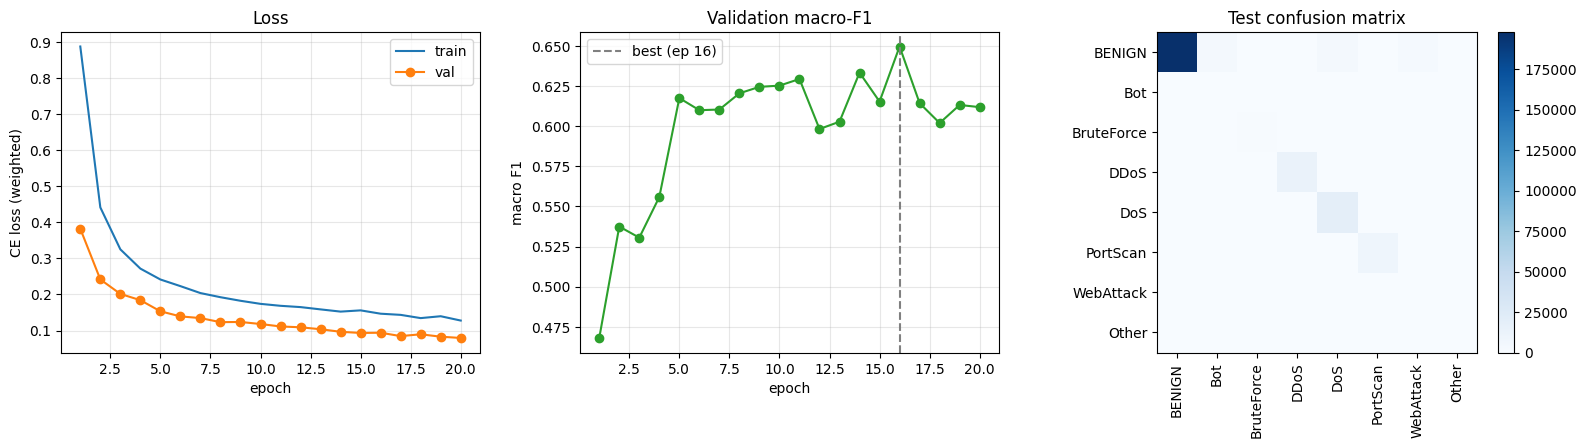

Saved: /content/netguard_train/netguard_curves.png


In [ ]:
# Plot  Training Curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

epochs_ran = range(1, len(history["train_loss"]) + 1)
axes[0].plot(epochs_ran, history["train_loss"], label="train")
axes[0].plot(epochs_ran, history["val_loss"], label="val", marker="o")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("CE loss (weighted)")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, history["val_macro_f1"], marker="o", color="tab:green")
axes[1].axvline(best_epoch, ls="--", c="gray", label=f"best (ep {best_epoch})")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("macro F1")
axes[1].set_title("Validation macro-F1"); axes[1].legend(); axes[1].grid(alpha=0.3)

im = axes[2].imshow(cm, cmap="Blues")
axes[2].set_xticks(range(len(class_names))); axes[2].set_xticklabels(class_names, rotation=90)
axes[2].set_yticks(range(len(class_names))); axes[2].set_yticklabels(class_names)
axes[2].set_title("Test confusion matrix")
plt.colorbar(im, ax=axes[2], fraction=0.046)

plt.tight_layout()
plot_path = os.path.join(LOCAL_DIR, "netguard_curves.png")
plt.savefig(plot_path, dpi=120)
plt.show()
print(f"Saved: {plot_path}")

## Export to ONNX

In [ ]:
model.eval()
model_cpu = NetGuard(n_features=N_FEATURES, n_classes=len(class_names))
model_cpu.load_state_dict(torch.load(best_ckpt_path, map_location="cpu"))
model_cpu.eval()

NetGuard(
  (convs): ModuleList(
    (0): Conv1d(1, 64, kernel_size=(3,), stride=(1,))
    (1): Conv1d(1, 64, kernel_size=(5,), stride=(1,))
    (2): Conv1d(1, 64, kernel_size=(7,), stride=(1,))
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=192, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=8, bias=True)
)

In [ ]:
# Dummy test check
dummy = torch.randn(1, N_FEATURES, dtype=torch.float32)
onnx_path = os.path.join(LOCAL_DIR, "netguard.onnx")

In [ ]:
print(f"Exported: {onnx_path} ({os.path.getsize(onnx_path)/1e6:.2f} MB)")

Exported: /content/netguard_train/netguard.onnx (0.00 MB)


In [ ]:
import onnxruntime as ort

In [ ]:
session = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])

In [ ]:
# Flow Featues
sample = X_test[:256].astype(np.float32)
onnx_logits = session.run(None, {"flow_features": sample})[0]

In [ ]:
# Not training torch call
with torch.no_grad():
    torch_logits = model_cpu(torch.from_numpy(sample)).numpy()

In [ ]:
max_diff = np.abs(onnx_logits - torch_logits).max()

In [ ]:
print(f"Max logit difference ONNX vs PyTorch: {max_diff:.2e}")
assert max_diff < 1e-3, "ONNX export diverges from PyTorch — do not deploy this"
print("ONNX verification passed.")

Max logit difference ONNX vs PyTorch: 0.00e+00
ONNX verification passed.


In [ ]:
t0 = time.time()
for _ in range(100):
    session.run(None, {"flow_features": X_test[:1].astype(np.float32)})
print(f"CPU latency, single flow: {(time.time()-t0)/100*1000:.2f} ms")


CPU latency, single flow: 0.16 ms


In [ ]:
torch.save(model_cpu.state_dict(), os.path.join(LOCAL_DIR, "netguard_best.pt"))

In [ ]:
# Save onnx model ready for production in AI Agent tool
train_metadata = {
    "model_name": "NetGuard",
    "version": "v1",
    "role": "auxiliary network-flow classifier feeding structured scores to the LLM orchestrator (Agithar)",
    "dataset": "CICIDS2017 (chethuhn/network-intrusion-dataset mirror)",
    "task": "multi-class attack category classification (8 classes), tabular CNN1D, no embedding layer",
    "architecture": {
        "type": "TextCNN-family, parallel multi-kernel Conv1D over the raw feature vector",
        "n_features": N_FEATURES,
        "kernel_sizes": list(KERNEL_SIZES),
        "filters_per_branch": NUM_FILTERS,
        "hidden_dim": HIDDEN_DIM,
        "dropout": DROPOUT,
        "trainable_params": int(n_params),
    },
    "class_names": class_names,
    "class_weights": {n: float(w) for n, w in zip(class_names, capped)},
    "known_limitation": (
        "'Other' (merged Infiltration+Heartbleed) has ~36 training samples — too few for "
        "reliable learning regardless of architecture. Expect weak recall on this class "
        "specifically; see the test classification report."
    ),
    "training": {
        "loss": "CrossEntropyLoss with inverse-frequency class weights (capped)",
        "optimizer": "AdamW",
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "epochs_ran": len(history["train_loss"]),
        "best_epoch": int(best_epoch),
        "seed": SEED,
    },
    "metrics_test": {
        "macro_f1": float(test_macro_f1),
        "weighted_f1": float(test_weighted_f1),
        "accuracy_context_only": float(test_accuracy),
        "derived_binary_f1": float(binary_f1),
        "confusion_matrix": cm.tolist(),
        "note": "macro_f1 is the model-selection metric; accuracy is context only (83% BENIGN baseline)",
    },
    "history": history,
    "inference_contract": {
        "input": "float32 vector of scaled flow features, shape (1, n_features)",
        "output": "logits over class_names; apply softmax for probabilities, argmax for prediction",
        "example": {"predicted_class": "DDoS", "confidence": 0.91},
        "deployment": "ONNX Runtime, CPU, inside the FastAPI backend",
    },
}

In [ ]:
with open(os.path.join(LOCAL_DIR, "metadata.json"), "w") as f:
    json.dump(train_metadata, f, indent=2)


In [ ]:
print("Local artifacts:")
for fn in sorted(os.listdir(LOCAL_DIR)):
    p = os.path.join(LOCAL_DIR, fn)
    if os.path.isfile(p):
        print(f"  {fn}  ({os.path.getsize(p)/1e6:.2f} MB)")


Local artifacts:
  metadata.json  (0.00 MB)
  netguard.onnx  (0.00 MB)
  netguard.onnx.data  (0.11 MB)
  netguard_best.pt  (0.11 MB)
  netguard_curves.png  (0.11 MB)


In [ ]:
! ls -lah /content/netguard_train

total 360K
drwxr-xr-x 3 root root 4.0K Aug 21 16:11 .
drwxr-xr-x 1 root root 4.0K Aug 21 14:50 ..
drwxr-xr-x 2 root root 4.0K Aug 21 15:15 checkpoints
-rw-r--r-- 1 root root 4.7K Aug 21 16:11 metadata.json
-rw-r--r-- 1 root root 110K Aug 21 16:10 netguard_best.pt
-rw-r--r-- 1 root root 112K Aug 21 16:05 netguard_curves.png
-rw-r--r-- 1 root root 4.3K Aug 21 16:08 netguard.onnx
-rw-r--r-- 1 root root 105K Aug 21 16:08 netguard.onnx.data


## Send Artifcats to my Drive from Colab VM

In [ ]:
os.makedirs(DRIVE_OUT, exist_ok=True)
for fn in ("netguard.onnx", "netguard_best.pt", "metadata.json", "netguard_curves.png"):
    src = os.path.join(LOCAL_DIR, fn)
    if os.path.exists(src):
        shutil.copy(src, os.path.join(DRIVE_OUT, fn))

In [ ]:
print(f"Copied to Drive: {DRIVE_OUT}")
for fn in sorted(os.listdir(DRIVE_OUT)):
    print(f"  {fn}")


Copied to Drive: /content/drive/MyDrive/Aegis-CyberSec-Guard/netguard/modelV1
  metadata.json
  netguard.onnx
  netguard_best.pt
  netguard_curves.png


In [ ]:
# Inference Contract Demo
def netguard_predict(session, feature_batch, class_names):
    logits = session.run(None, {"flow_features": feature_batch.astype(np.float32)})[0]
    exp = np.exp(logits - logits.max(axis=1, keepdims=True))
    probs = exp / exp.sum(axis=1, keepdims=True)
    pred_idx = probs.argmax(axis=1)
    return [
        {"predicted_class": class_names[i], "confidence": round(float(probs[row, i]), 4)}
        for row, i in enumerate(pred_idx)
    ]

In [ ]:
sample_idx = {name: int(np.where(y_test_mc == i)[0][0])
              for i, name in enumerate(class_names) if (y_test_mc == i).any()}


In [ ]:
for name, idx in sample_idx.items():
    result = netguard_predict(session, X_test[idx:idx+1], class_names)[0]
    print(f"known {name:12s} (test index {idx}): {json.dumps(result)}")

known BENIGN       (test index 0): {"predicted_class": "Bot", "confidence": 0.5506}
known Bot          (test index 1692): {"predicted_class": "BENIGN", "confidence": 0.4392}
known BruteForce   (test index 311): {"predicted_class": "BruteForce", "confidence": 1.0}
known DDoS         (test index 21): {"predicted_class": "DDoS", "confidence": 1.0}
known DoS          (test index 4): {"predicted_class": "DoS", "confidence": 1.0}
known PortScan     (test index 17): {"predicted_class": "PortScan", "confidence": 1.0}
known WebAttack    (test index 131): {"predicted_class": "BENIGN", "confidence": 0.3789}
known Other        (test index 39689): {"predicted_class": "WebAttack", "confidence": 0.6089}


In [ ]:
torch.onnx.export(
    model_cpu, dummy, onnx_path,
    input_names=["flow_features"], output_names=["logits"],
    dynamic_axes={"flow_features": {0: "batch"}, "logits": {0: "batch"}},
    opset_version=17,
    export_params=True,
    dynamo=False,
)

/tmp/ipykernel_983/189967106.py:1: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


In [ ]:
!cp /content/netguard_train/netguard.onnx  /content/drive/MyDrive/Aegis-CyberSec-Guard/netguard/modelV1


In [ ]:
! ls -lah /content/netguard_train

total 460K
drwxr-xr-x 3 root root 4.0K Aug 21 16:11 .
drwxr-xr-x 1 root root 4.0K Aug 21 14:50 ..
drwxr-xr-x 2 root root 4.0K Aug 21 15:15 checkpoints
-rw-r--r-- 1 root root 4.7K Aug 21 16:11 metadata.json
-rw-r--r-- 1 root root 110K Aug 21 16:10 netguard_best.pt
-rw-r--r-- 1 root root 112K Aug 21 16:05 netguard_curves.png
-rw-r--r-- 1 root root 108K Aug 21 16:18 netguard.onnx
-rw-r--r-- 1 root root 105K Aug 21 16:08 netguard.onnx.data


In [ ]:
!cp /content/netguard_train/netguard.onnx.data /content/drive/MyDrive/Aegis-CyberSec-Guard/netguard/